# Extracting component signals from AX3 recordings

SOOO pyEMD not related to empirical mode decompisition os this blog post is probably AI hallucination? What a waste.
https://towardsdatascience.com/preprocessing-signal-data-with-empirical-mode-decomposition/
https://pypi.org/project/pyemd/
updated but maintained but under POT https://pythonot.github.io/ 

or
https://emd.readthedocs.io/en/stable/emd_tutorials/01_sifting/emd_tutorial_01_sift_01_siftintro.html#sphx-glr-emd-tutorials-01-sifting-emd-tutorial-01-sift-01-siftintro-py
https://emd.readthedocs.io/en/stable/install.html#quick-start

last updated march 2025


Using masking frequencies to identify IMFs with relevant behaviours: Respiration, clapping/posture



In [1]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import emd

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d
from scipy import ndimage
from scipy import signal


In [2]:
datapath = '/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/Naive/'
sources = os.listdir(datapath)
print(sources)
sources = ['rgb', 'ir', 'thermalhandheld', 'thermalbox', 'therdata','ax3','jerk','blackmagic_rgb', 'blackmagic_ir','blackmagic_thermal']
samplerates=dict(zip(sources,[59.97,59.97,25,50,4,400,400,60,60,60]))
# inconsitent sampling: therdata, ax3, jerk


fileName = '/motion_normalized_roi_sizes.csv'

['blackmagic_thermal', 'filt_acc', 'thermalboxtest_Claps.csv', 'ax3est_RESP.csv', 'filt_jerk10Hz', '.DS_Store', 'acc_dimtest_Claps.csv', 'ir', 'filt_acc10Hz', 'thermalhandheld', 'thermalbox', 'thermalboxtest_RESP.csv', 'rgb', 'therdata', 'blackmagic_rgb', 'irtest_Claps.csv', 'jerk', 'filt_jerk', 'readme.txt', 'irtest_RESP.csv', 'blackmagic_ir', 'ax3', 'acc_dim', 'acc_dimtest_RESP.csv', 'ax3_copy', 'ax3est_Claps.csv']


In [3]:
s = 'acc_dim'
QoM = pd.read_csv(datapath+s+fileName,index_col = 18)

In [4]:
ts = 60
te = 415
Resp = QoM.loc[ts:te,:].copy()
Clap = QoM.loc[ts:te,:].copy()

In [5]:
Resp

,AU1_X,AU1_Y,AU1_Z,AU2_X,AU2_Y,AU2_Z,AU3_X,AU3_Y,AU3_Z,AU4_X,AU4_Y,AU4_Z,AU5_X,AU5_Y,AU5_Z,AU7_X,AU7_Y,AU7_Z
timestamp,,,,,,,,,,,,,,,,,,
60.0025,0.000218,0.870909,0.484525,0.134719,0.843731,0.500121,-0.057252,0.904671,0.486621,-0.167659,0.953762,0.021933,0.045393,0.965348,0.309118,-0.165484,0.887664,0.303999
60.0050,0.000162,0.868195,0.484618,0.131902,0.843725,0.500494,-0.059499,0.903431,0.489474,-0.166861,0.953461,0.022916,0.046504,0.965861,0.307324,-0.164342,0.888487,0.303812
60.0075,0.000080,0.865737,0.484612,0.130744,0.843728,0.501042,-0.058966,0.902919,0.492530,-0.166496,0.954140,0.022371,0.047019,0.967036,0.304839,-0.163181,0.888926,0.305551
60.0100,0.000022,0.864483,0.484316,0.131854,0.843732,0.501466,-0.055399,0.903550,0.494814,-0.166755,0.955442,0.020318,0.047135,0.968099,0.302991,-0.162285,0.889291,0.308386
60.0125,-0.000006,0.864545,0.483498,0.135299,0.843736,0.501093,-0.050484,0.904769,0.496341,-0.167913,0.956776,0.018502,0.047073,0.968711,0.302373,-0.161689,0.889677,0.310950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414.9900,0.019253,0.881345,0.465046,0.182447,0.807094,0.536369,-0.044623,0.906081,0.484365,-0.093120,0.909547,0.278644,0.037991,0.977960,0.289474,-0.157627,0.876288,0.337322
414.9925,0.018984,0.884485,0.466999,0.180567,0.805680,0.536413,-0.044769,0.906835,0.484357,-0.092043,0.907357,0.279037,0.039488,0.980043,0.288546,-0.156674,0.876487,0.337341
414.9950,0.017866,0.887409,0.470777,0.178459,0.803579,0.535192,-0.043661,0.908861,0.484353,-0.090813,0.906766,0.280060,0.041392,0.978959,0.287251,-0.156194,0.878217,0.336965


<Axes: xlabel='timestamp'>

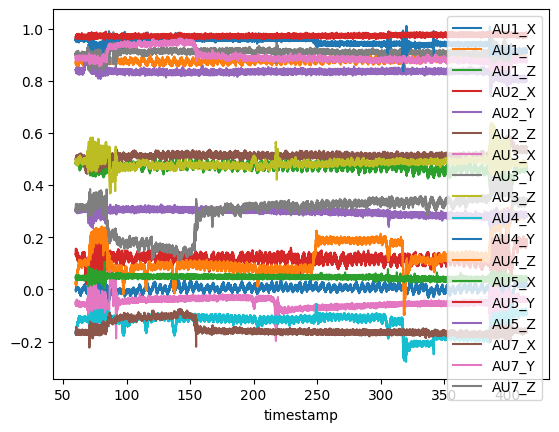

In [6]:
QoM.loc[ts:te,:].plot()

https://emd.readthedocs.io/en/stable/emd_tutorials/01_sifting/emd_tutorial_01_sift_04_masksift.html

https://emd.readthedocs.io/en/stable/emd_tutorials/01_sifting/emd_tutorial_01_sift_06_siftconfig.html

In [7]:
partID = 'AU5'
part_dims = [partID+'_X',partID+'_Y',partID+'_Z']

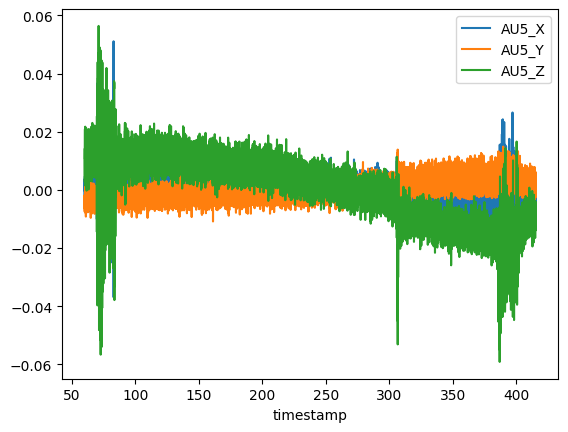

In [11]:
#initial lowpass filtering 
fs = 400
filtering_range = 25 
cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
nyq = 0.5 * fs 
order = 2 
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='lowpass', analog=False)


for i in range(3):
    signal = QoM.loc[ts:te,part_dims[i]].copy()
    signal = signal-signal.mean()
    signal.loc[:] = filtfilt(b, a, signal)
    signal.plot(label = part_dims[i])
plt.legend()

In [12]:
resp_dims = ['AU1_Z','AU1_Y','AU2_X','AU2_Z','AU3_Z','AU3_Y','AU4_Z','AU4_X','AU5_Z','AU7_Z']

time_s = QoM.loc[ts:te,:].index
Resp = pd.DataFrame(index=time_s,columns = resp_dims ,dtype="float") 
Clap = pd.DataFrame(index=time_s,columns = resp_dims ,dtype="float") 

In [22]:
Clap = pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/'+ 'acc_dimtest_Claps.csv',index_col=0)
Resp= pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/'+ 'acc_dimtest_RESP.csv',index_col=0)


## Initial treatment of measurements
Starting from the acceleration magnitude (QoM) resampled to 400 Hz. 

AU7_Z


<Axes: xlabel='timestamp'>

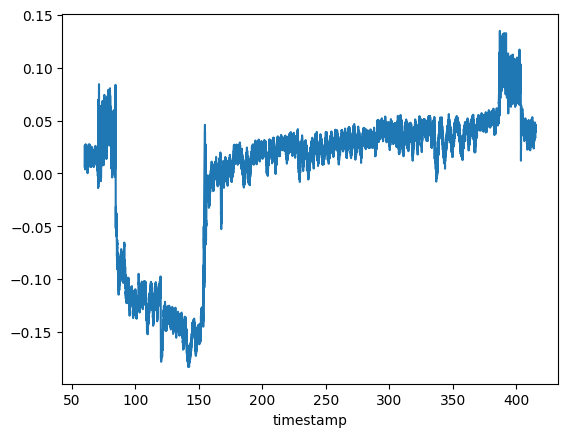

In [79]:
partID = resp_dims[9]
print(partID)

signal = QoM.loc[ts:te,partID].copy()
signal = signal-signal.mean()
signal.loc[:] = filtfilt(b, a, signal)
# (QoM.loc[ts:te,partID]-QoM.loc[ts:te,partID].mean()).plot()
signal.plot()

<Axes: xlabel='Time (samples)'>

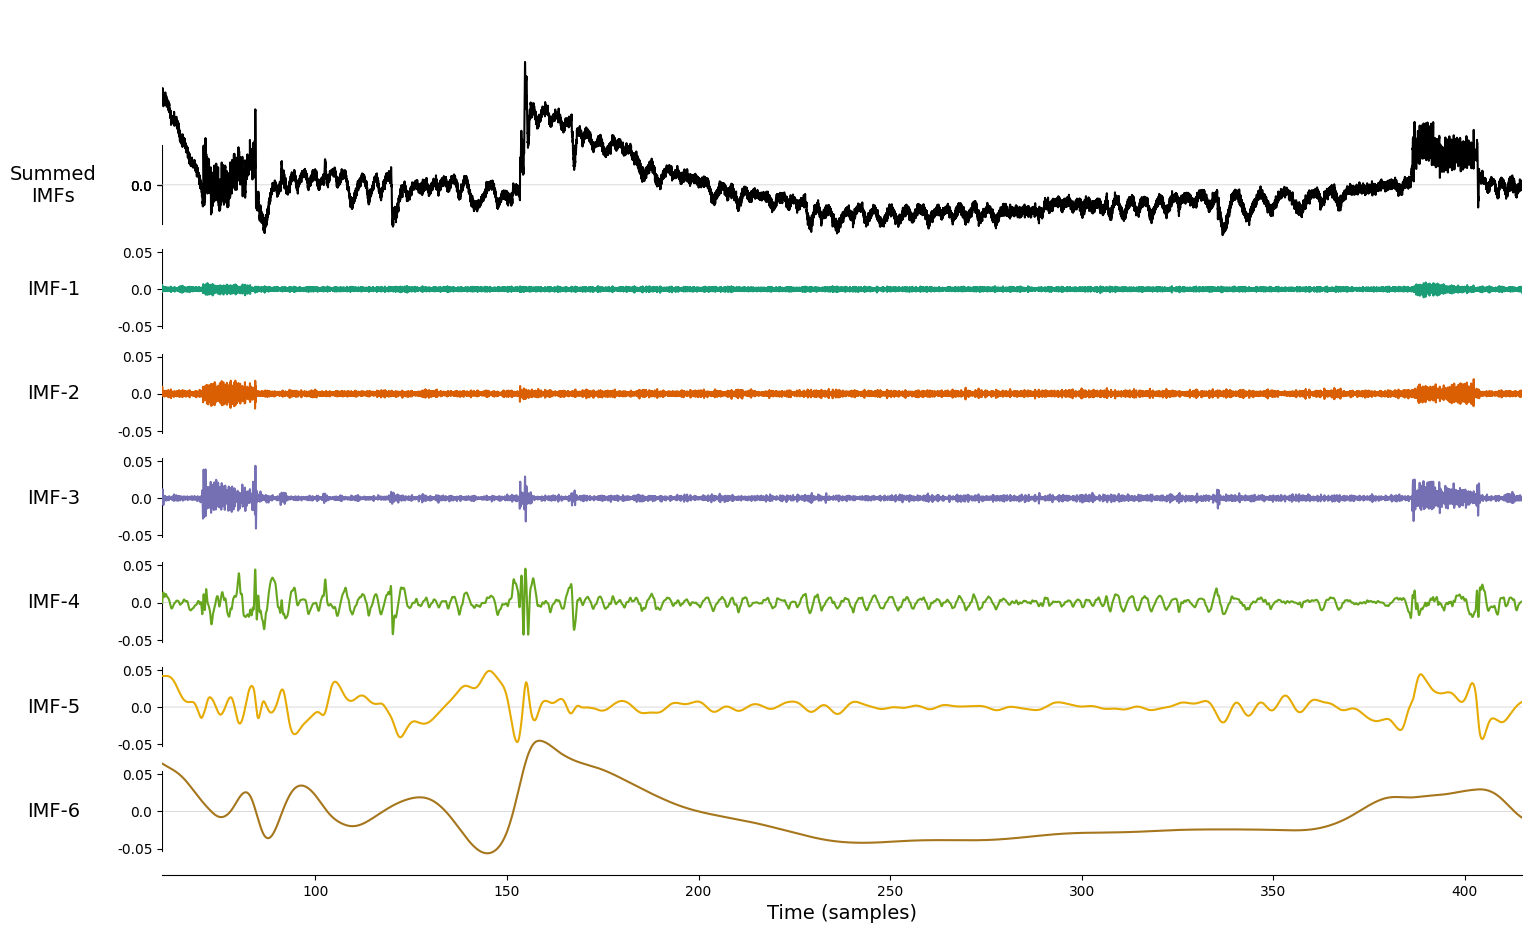

In [80]:
mask = np.array([30, 12, 3, 0.3, 0.05,0.005])/fs
imf = emd.sift.mask_sift(signal.values, max_imfs=6, mask_freqs=mask)
# fig,axes = plt.subplots(len(imf[0]),1,figsize=(15,2*len(imf[0])))
# for i in range(len(imf[0])):
#     axes[i].plot(signal.index,imf[:,i])
# plt.show()
emd.plotting.plot_imfs(imf, time_vect=signal.index)


Text(0.5, 1.0, 'Components of signal extraction, mid during resp dominant interval')

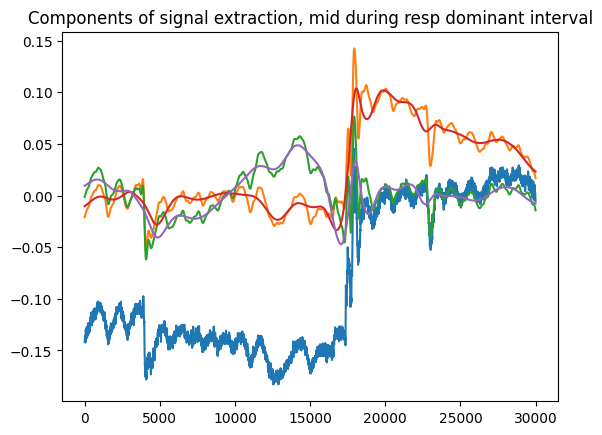

In [81]:

plt.plot(signal.iloc[20000:50000].values)
plt.plot(imf[20000:50000,4]+imf[20000:50000,3]+imf[20000:50000,5])
plt.plot(imf[20000:50000,4]+imf[20000:50000,3])#+imf[20000:50000,5])
plt.plot(imf[20000:50000,4]+imf[20000:50000,5])
plt.plot(imf[20000:50000,4])
plt.title('Components of signal extraction, mid during resp dominant interval')

Text(0.5, 1.0, 'Components of signal extraction, high during clapping dominant interval')

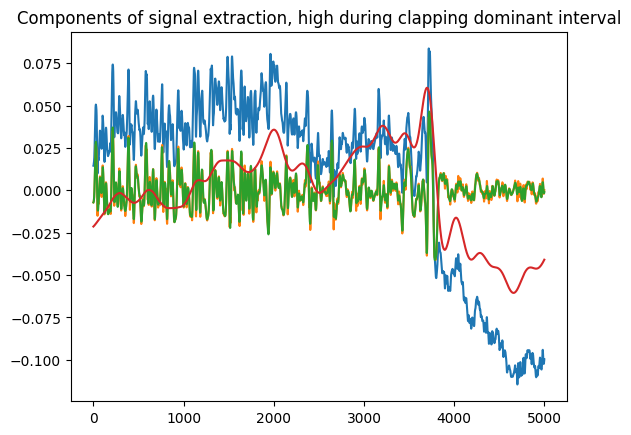

In [82]:
plt.plot(signal.iloc[6000:11000].values)
plt.plot(imf[6000:11000,0]+imf[6000:11000,1]+imf[6000:11000,2])
plt.plot(imf[6000:11000,1]+imf[6000:11000,2])
plt.plot(imf[6000:11000,3]+imf[6000:11000,4]+imf[6000:11000,5])
plt.title('Components of signal extraction, high during clapping dominant interval')

In [23]:
Resp.loc[:,partID] = imf[:,4]+imf[:,5]+imf[:,3] #4,5 for AU5_Z and AU7_Z
Clap.loc[:,partID] = imf[:,1]+imf[:,2] 

In [83]:
Resp.loc[:,partID] = imf[:,4]+imf[:,3]#+imf[:,5] #4,5 for AU5_Z and AU7_Z
Clap.loc[:,partID] = imf[:,1]+imf[:,2] 

### after Running through plausible dimensions from all 6 participants

In [86]:
Resp.to_csv(datapath+s+'test_RESP.csv')
Clap.to_csv(datapath+s+'test_Claps.csv')

# Recalculate Jerk

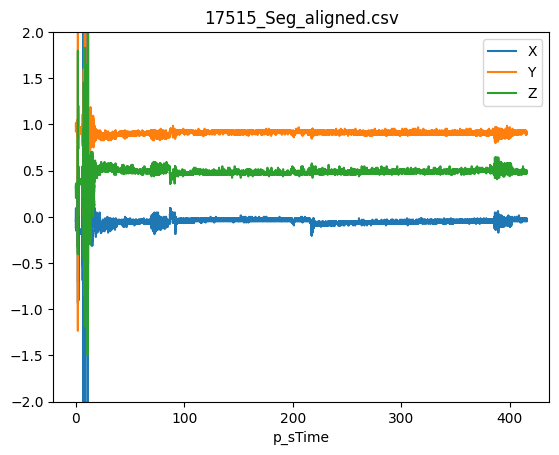

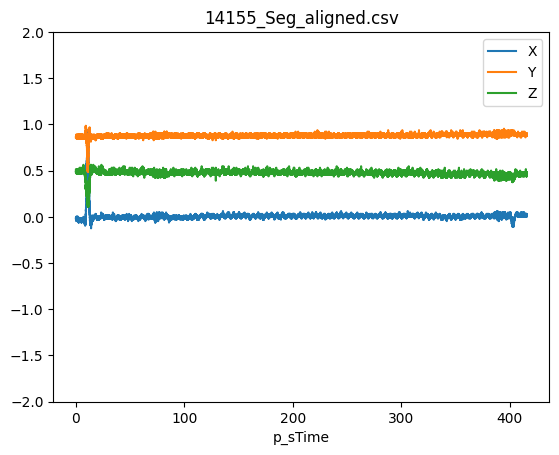

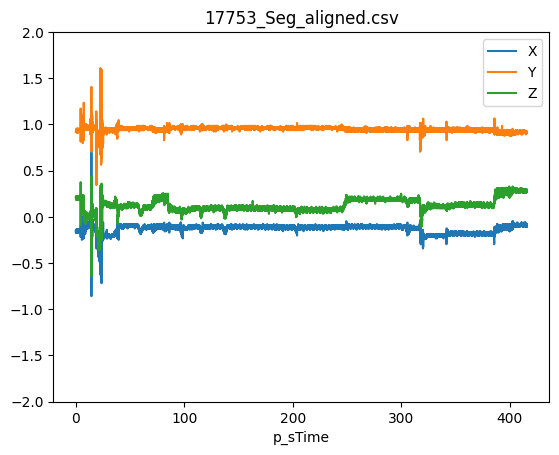

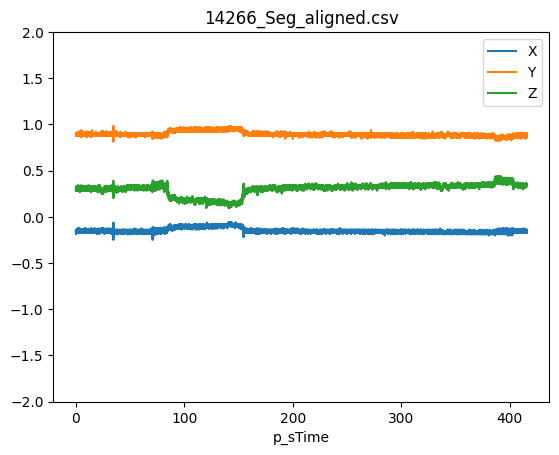

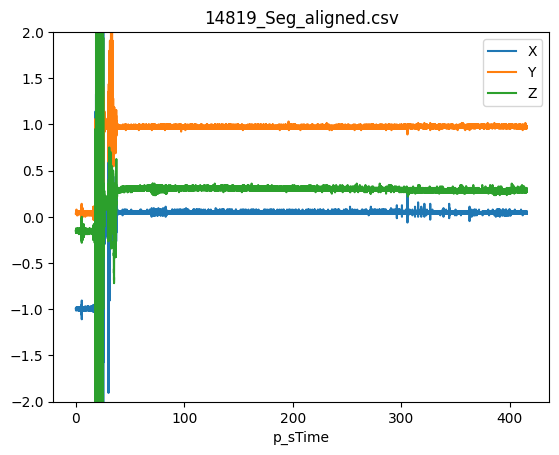

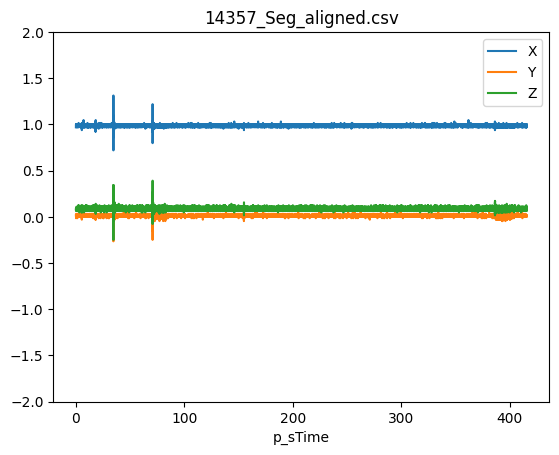

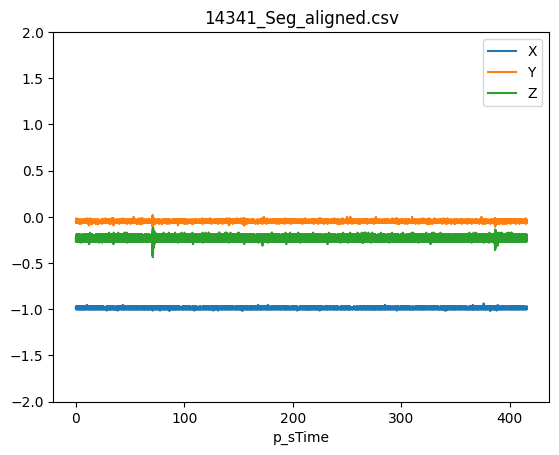

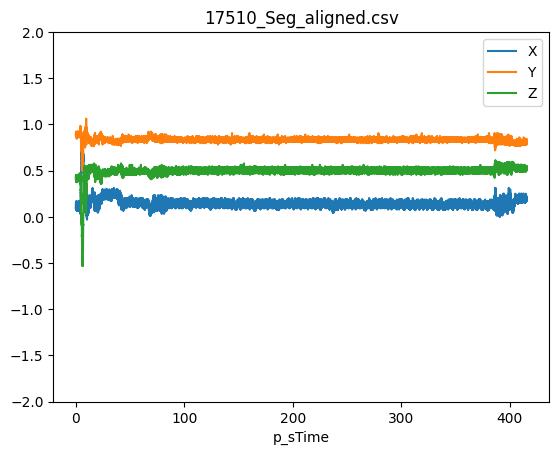

In [162]:
fileloc = '../Excerpt/AX3/'

files = os.listdir(fileloc)

for f in files:
    df_acc = pd.read_csv(fileloc+f,index_col=0)
    df_acc.set_index('p_sTime',drop=True,inplace=True)
    df_acc.loc[:,['X', 'Y', 'Z',]].plot()
    plt.title(f)
    plt.ylim([-2,2])
    plt.show()

In [166]:
df_acc.columns

Index(['X', 'Y', 'Z', 'rec_sTime', 'rec_dTime', 'dev_dTime'], dtype='object')

In [11]:
fileloc = '../Excerpt/AX3/'
ax3s={'AU1':'14155_Seg_aligned.csv',
 'AU2':'17510_Seg_aligned.csv',
 'AU3':'17515_Seg_aligned.csv',
 'AU4':'17753_Seg_aligned.csv',
 'AU5':'14819_Seg_aligned.csv',
 'AU7':'14266_Seg_aligned.csv',}
fs = 400
alt_fs = 10
time_s = np.arange(0.005,415.875,1/fs)
time_salt = np.arange(0.005,415.875,1/alt_fs)

datapath = '/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/Naive/'
fileName = 'motion_normalized_roi_sizes.csv'

In [12]:
#initial lowpass filtering 
filtering_range = 10 
cutoff = np.array(filtering_range) #cutoff = np.array([0.05,1]) 
nyq = 0.5 * fs 
order = 2 
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='lowpass', analog=False)

In [15]:
filtacc = pd.DataFrame(index = time_s,columns = ax3s.keys())
jerks= pd.DataFrame(index = time_s,columns = ax3s.keys())
filtacc_alt = pd.DataFrame(index = time_salt,columns = ax3s.keys()) 
jerks_alt= pd.DataFrame(index = time_salt,columns = ax3s.keys())
acc_dim =pd.DataFrame(index = time_s)
for PartID in ax3s.keys():
    df_acc = pd.read_csv(fileloc+ax3s[PartID],index_col=1)
    acc = pd.DataFrame(index=time_s,columns = ['X', 'Y', 'Z'],dtype="float") # I can't believe I need to specify this wtf pandas why
    acc_alt = pd.DataFrame(index=time_salt,columns = ['X', 'Y', 'Z'],dtype="float") # I can't believe I need to specify this wtf pandas why

    for col in ['X', 'Y', 'Z']:
        f = interp1d(df_acc.index,df_acc[col])
        acc.loc[:,col]=filtfilt(b, a, f(time_s)) # resample and lowpass filter
        acc_dim.loc[:,PartID + '_'+col]=filtfilt(b, a, f(time_s))
        
        f = interp1d(acc.index,acc[col])
        acc_alt.loc[:,col]=f(time_salt)
    filtacc.loc[:,PartID] = np.sqrt((acc['X']**2)+(acc['Y']**2)+(acc['Z']**2))
    jerks.loc[:,PartID] = np.sqrt(np.square(acc.loc[:,['X','Y','Z']].diff()).sum(axis=1))
    filtacc_alt.loc[:,PartID] = np.sqrt((acc_alt['X']**2)+(acc_alt['Y']**2)+(acc_alt['Z']**2))
    jerks_alt.loc[:,PartID] = np.sqrt(np.square(acc_alt.loc[:,['X','Y','Z']].diff()).sum(axis=1))

filtacc.loc[:,'timestamp'] = time_s
jerks.loc[:,'timestamp'] = time_s
acc_dim.loc[:,'timestamp'] = time_s
jerks_alt.loc[:,'timestamp'] = time_salt
acc_alt.loc[:,'timestamp'] = time_salt

filtacc.to_csv(datapath + 'filt_acc/'+fileName,index=False)
jerks.to_csv(datapath + 'filt_jerk/'+fileName,index=False)
filtacc_alt.to_csv(datapath + 'filt_acc10Hz/'+fileName,index=False)
jerks_alt.to_csv(datapath + 'filt_jerk10Hz/'+fileName,index=False)
acc_dim.to_csv(datapath + 'acc_dim/'+fileName,index=False)


# Hilbert spectrum of acc


<Axes: xlabel='Time (samples)'>

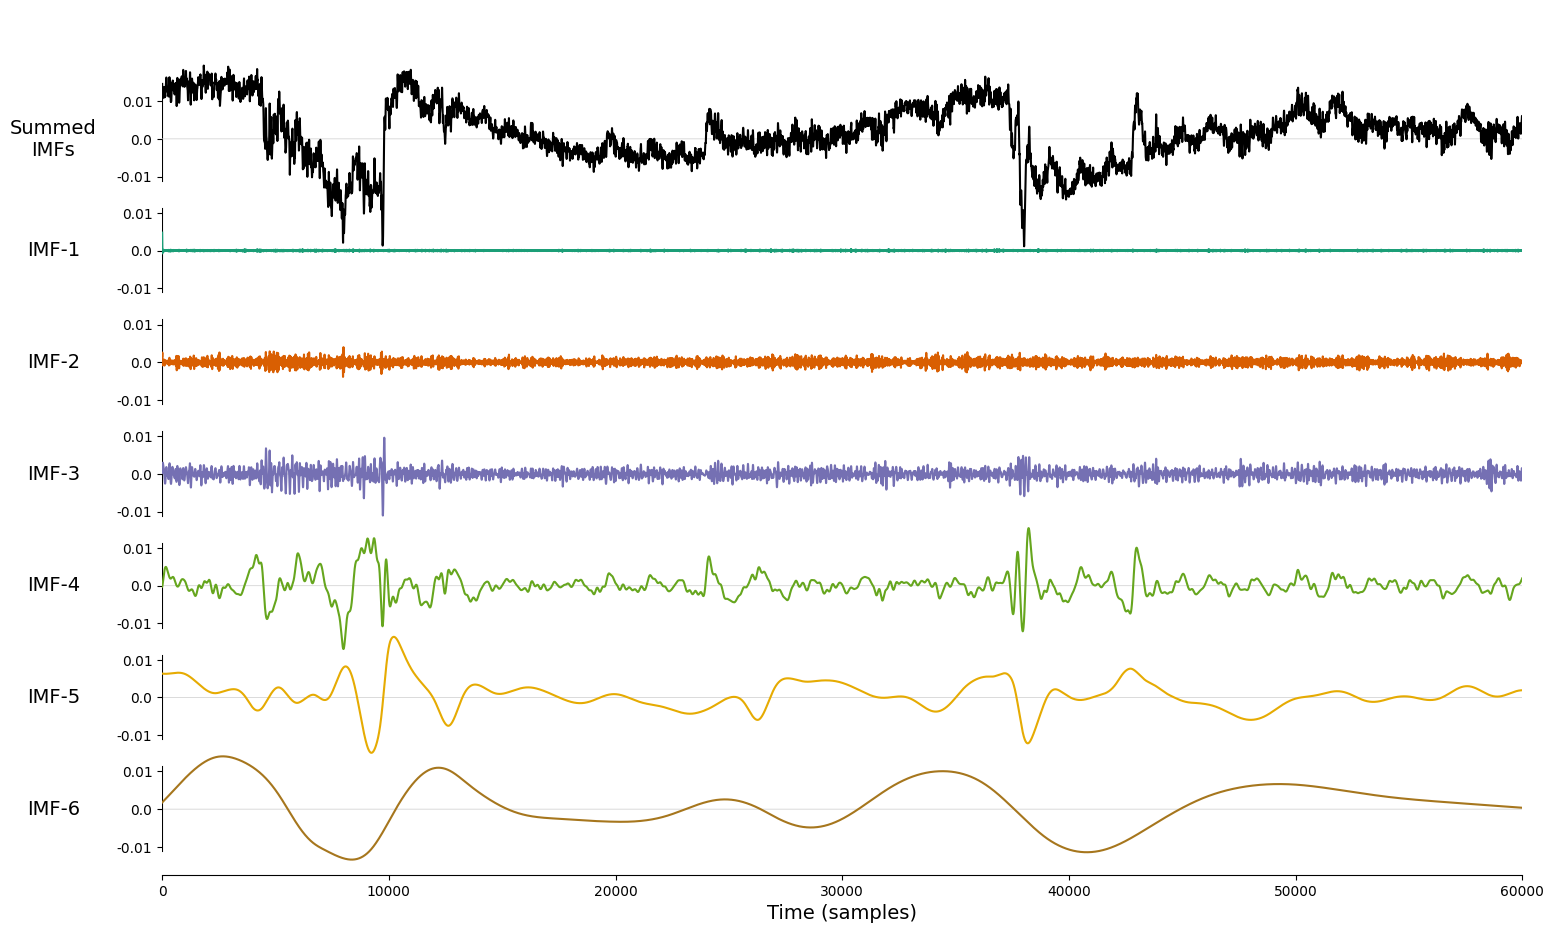

In [147]:
# config = emd.sift.get_config('mask_sift')
# config['max_imfs'] = 7
# config['mask_freqs'] = 50/sample_rate
# config['mask_amp_mode'] = 'ratio_sig'
# config['imf_opts/sd_thresh'] = 0.05
# imf = emd.sift.mask_sift(x, **config)
IP, IF, IA = emd.spectra.frequency_transform(imf, fs, 'nht')

# Visualise the IMFs
emd.plotting.plot_imfs(imf[:fs*150, :])


In [148]:
from scipy import ndimage
import matplotlib.patches as patches

<Axes: xlabel='Time (samples)'>

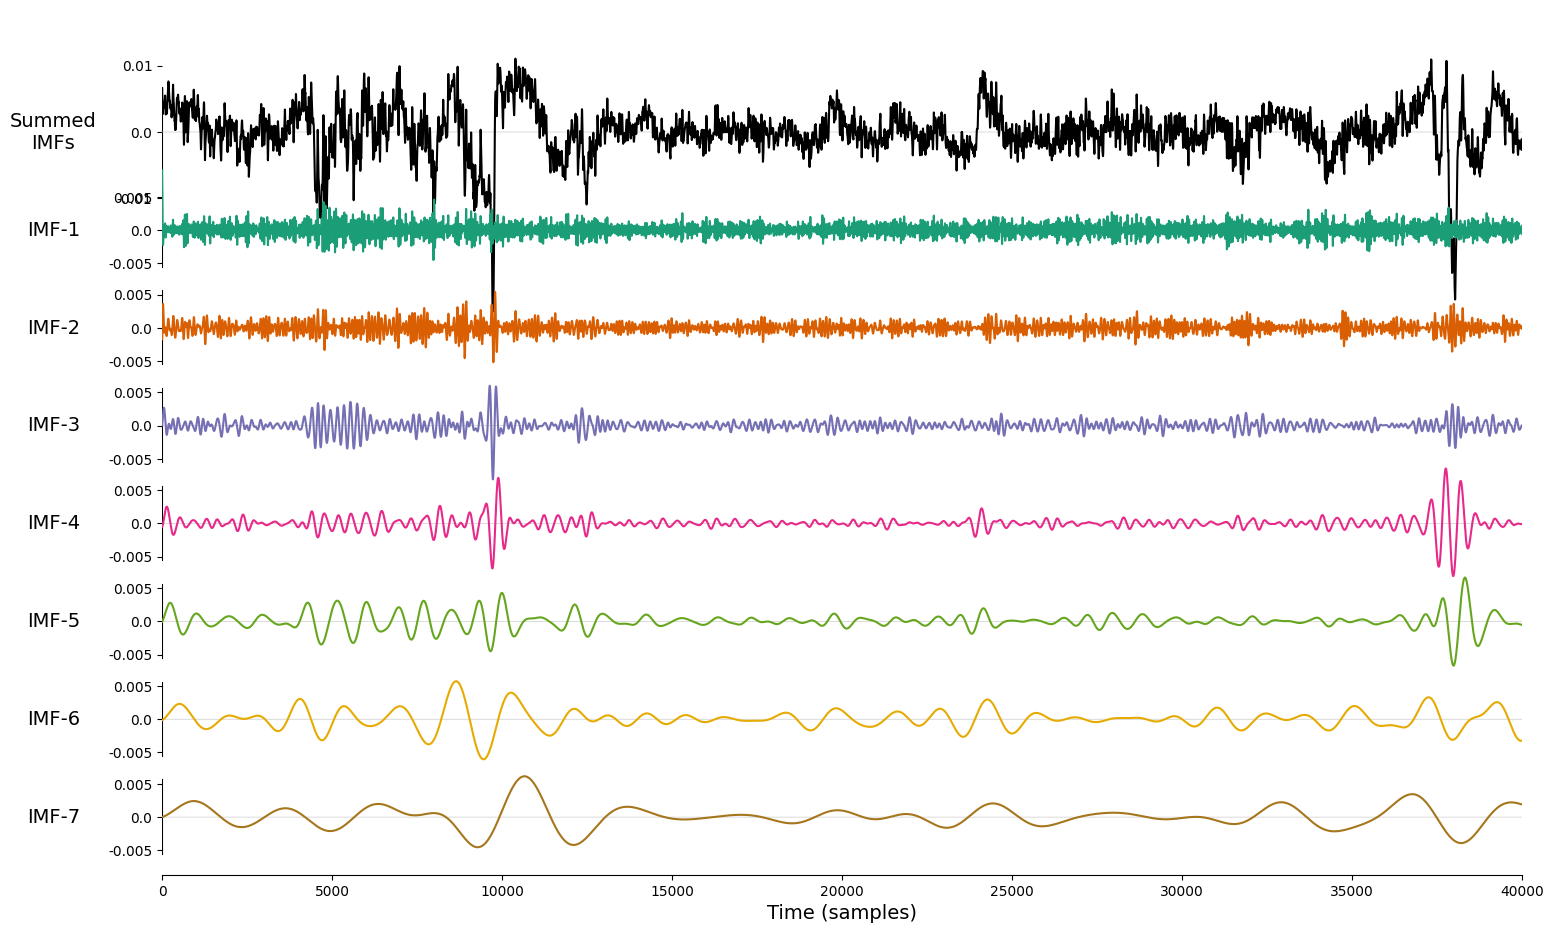

In [150]:
# Run a mask sift
imf = emd.sift.mask_sift(signal.values, max_imfs=7)

emd.plotting.plot_imfs(imf[:fs*100, :])



In [151]:
# Compute frequency statistics
IP, IF, IA = emd.spectra.frequency_transform(imf[:fs*100, :], fs, 'nht')


Text(0.5, 0, 'Frequency (Hz)')

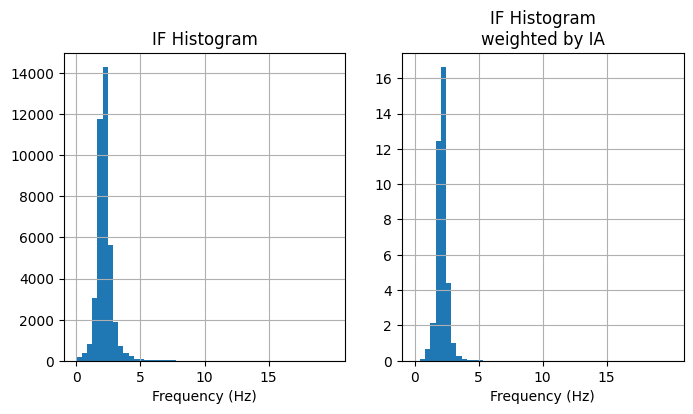

In [152]:
plt.figure(figsize=(8, 4))

plt.subplot(121)
# Plot a simple histogram using frequency bins from 0-20Hz
plt.hist(IF[:, 2], np.linspace(0, 20))
plt.grid(True)
plt.title('IF Histogram')
plt.xticks(np.arange(0, 20, 5))
plt.xlabel('Frequency (Hz)')

plt.subplot(122)
# Plot an amplitude-weighted histogram using frequency bins from 0-20Hz
plt.hist(IF[:, 2], np.linspace(0, 20), weights=IA[:, 2])
plt.grid(True)
plt.title('IF Histogram\nweighted by IA')
plt.xticks(np.arange(0, 20, 5))
plt.xlabel('Frequency (Hz)')

In [153]:
freq_edges, freq_centres = emd.spectra.define_hist_bins(0.1, 5, 128, 'linear')

# Amplitude weighted HHT per IMF
f, spec_weighted = emd.spectra.hilberthuang(IF, IA, freq_edges, sum_imfs=False)

# Unweighted HHT per IMF - we replace the instantaneous amplitude values with ones
f, spec_unweighted = emd.spectra.hilberthuang(IF, np.ones_like(IA), freq_edges, sum_imfs=False)


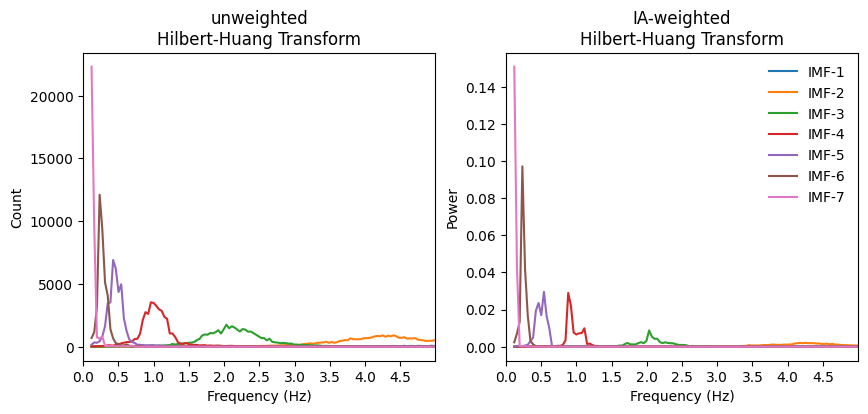

In [154]:

plt.figure(figsize=(10, 4))
plt.subplots_adjust(hspace=0.4)
plt.subplot(121)
plt.plot(freq_centres, spec_unweighted)
plt.xticks(np.arange(10)*0.5)
plt.xlim(0, 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('unweighted\nHilbert-Huang Transform')

plt.subplot(122)
plt.plot(freq_centres, spec_weighted)
plt.xticks(np.arange(10)*0.5)
plt.xlim(0,5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('IA-weighted\nHilbert-Huang Transform')
plt.legend(['IMF-1', 'IMF-2', 'IMF-3', 'IMF-4', 'IMF-5','IMF-6', 'IMF-7'], frameon=False)

In [155]:
IF[:, 4, None].mean()

0.4591344934426499

<Axes: xlabel='Time (samples)'>

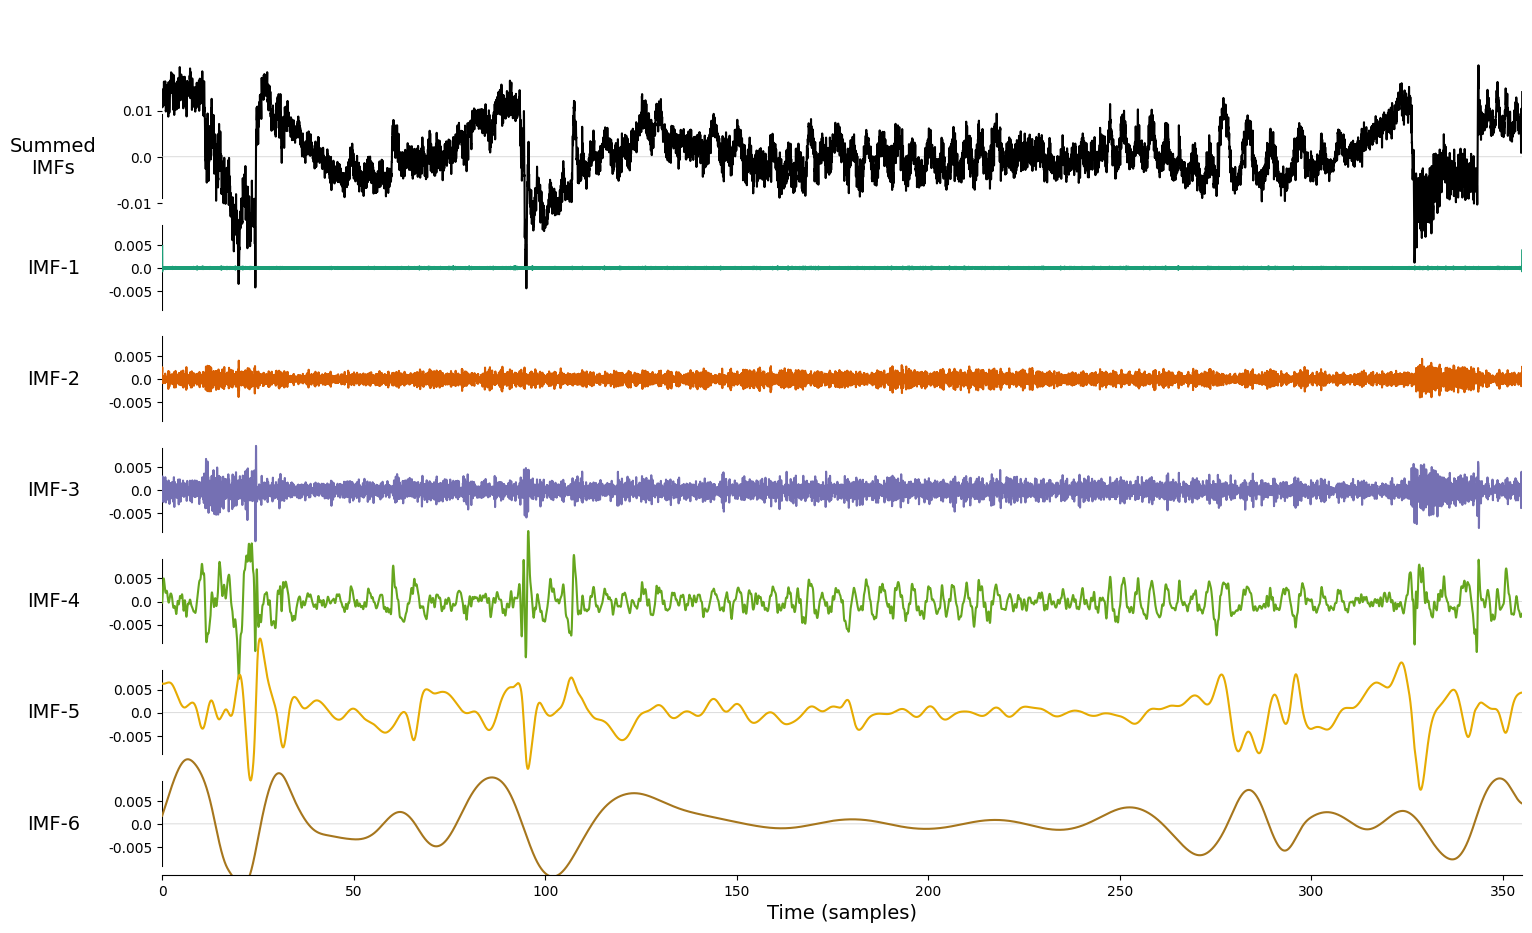

In [178]:
# imf = emd.sift.mask_sift(y, max_imfs=7)
time_vect = np.linspace(0, dur, dur*fs)
mask = np.array([30, 12, 3, 0.3, 0.05,0.005])/fs
imf = emd.sift.mask_sift(y, max_imfs=6, mask_freqs=mask)
time_vect = (signal.index)/fs
emd.plotting.plot_imfs(imf, time_vect=time_vect)


In [157]:
dur = 350
freq_edges, freq_centres = emd.spectra.define_hist_bins(0.05, 4, 256, 'linear')
time_centres = np.arange(dur*fs +1)-.5

IP, IF, IA = emd.spectra.frequency_transform(imf[:fs*dur, :], fs, 'nht')

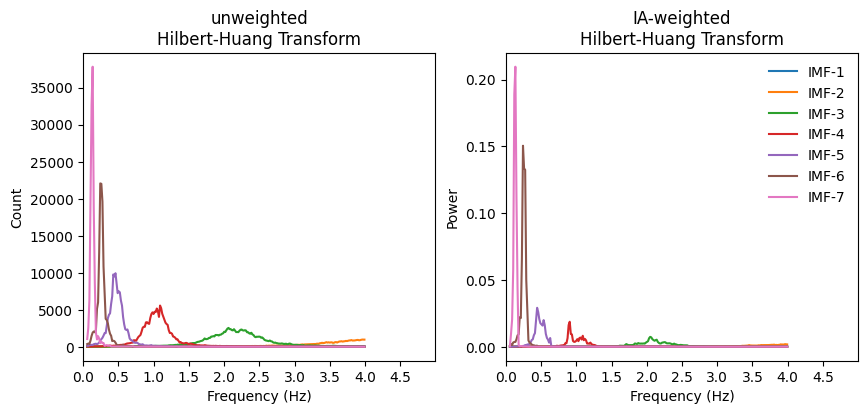

In [158]:
# Amplitude weighted HHT per IMF
f, spec_weighted = emd.spectra.hilberthuang(IF, IA, freq_edges, sum_imfs=False)

# Unweighted HHT per IMF - we replace the instantaneous amplitude values with ones
f, spec_unweighted = emd.spectra.hilberthuang(IF, np.ones_like(IA), freq_edges, sum_imfs=False)

plt.figure(figsize=(10, 4))
plt.subplots_adjust(hspace=0.4)
plt.subplot(121)
plt.plot(freq_centres, spec_unweighted)
plt.xticks(np.arange(10)*0.5)
plt.xlim(0, 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('unweighted\nHilbert-Huang Transform')

plt.subplot(122)
plt.plot(freq_centres, spec_weighted)
plt.xticks(np.arange(10)*0.5)
plt.xlim(0,5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('IA-weighted\nHilbert-Huang Transform')
plt.legend(['IMF-1', 'IMF-2', 'IMF-3', 'IMF-4', 'IMF-5','IMF-6', 'IMF-7'], frameon=False)

In [159]:
spec_weighted

array([[5.51955147e-06, 2.87358752e-06, 1.16937629e-06, ...,
        2.57488887e-05, 8.01874580e-04, 4.08235381e-04],
       [7.40152781e-07, 4.85099010e-06, 1.01936962e-06, ...,
        1.78352469e-05, 1.95444330e-03, 9.79056557e-03],
       [4.97965344e-06, 2.12826285e-06, 6.64665621e-06, ...,
        2.65230616e-05, 1.30639839e-03, 2.04977039e-02],
       ...,
       [5.68378583e-05, 1.91100956e-03, 4.83027123e-06, ...,
        2.97776836e-07, 0.00000000e+00, 0.00000000e+00],
       [5.33478442e-05, 1.84982402e-03, 3.22640032e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.36338063e-05, 1.73071399e-03, 4.43822367e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [21]:
plt.figure(figsize=(10, 6))

HHT = []
for imf_n in range(len(imf[0])):
    f, hht = emd.spectra.hilberthuang(IF[:, imf_n, None], IA[:, imf_n, None], freq_edges, mode='amplitude', sum_time=False)
    HHT.append(hht)
plt.axes([.1, .6, .64, .3])
plt.plot(y, 'k')
# plt.plot(IA[:, imf_n], 'r')
# plt.legend(['IMF', 'IA'])
plt.xlim(0, dur*fs)
HHT.append(hht)

H = HHT[0]
for i in range(1, len(HHT)): H += HHT[i]
    
# Add IF axis and legend
plt.axes([.1, .1, .8, .45])
# plt.plot(IF[:, imf_n], 'g', linewidth=1)
# plt.legend(['IF'])

# Plot HHT
plt.pcolormesh(time_centres, freq_edges,H[:, :dur*fs],  vmin=0,vmax=0.005) #cmap='hot_r',

# Set colourbar
cb = plt.colorbar()
cb.set_label('Amplitude', rotation=90)

plt.xlim(0, dur*fs)
plt.ylim(0, 4)
plt.xlabel('Time (samples)')
plt.ylabel('Frequency (Hz)')
plt.show

NameError: name 'IF' is not defined

<Figure size 1000x600 with 0 Axes>

len(imf[0])

The hilbert spectrum is messy for this masked fillered imfs because they aren't isolating the respiration well, however using the weighted spectruct to ID IMFs with resp info should then allow for automated extraction of a resp inclusive component to be handled by the respiration library
